In [10]:
# Notebook: Similar Artists
#
# Loads the most-rated artists by taking the union of user_songs (liked)
# and unliked_songs (disliked), then computes avg like rate and total
# rating count per artist.  Used as the basis for computing similar artists.

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
%matplotlib inline

# Connect to the museiq database and expose `connection`, `engine`, and `DB`
%run db.py

In [13]:
def get_most_rated_artists(start_date, min_ratings=20):
    """
    Load artists ranked by total number of ratings (likes + dislikes).

    Takes the union of:
    - user_songs   (liked=1, type=1 users only)
    - unliked_songs (liked=0)

    Returns a list of dicts with: artist_id, artist, cnt, avg_liked,
    num_fans, pop_decile — ordered by cnt desc.
    """
    sql = """
        SELECT artist_id,
               MAX(artist)     AS artist,
               COUNT(*)        AS cnt,
               AVG(liked)      AS avg_liked,
               MAX(num_fans)   AS num_fans,
               MAX(pop_decile) AS pop_decile
        FROM (
            SELECT c.artist_id, a.name AS artist, us.user_id, 1 AS liked,
                   a.num_fans, a.pop_decile
            FROM user_songs us
            INNER JOIN users u   ON us.user_id  = u.id
            INNER JOIN catalog c ON us.song_id  = c.id
            INNER JOIN artists a ON c.artist_id = a.id
            WHERE us.seq != 1
              AND us.timestamp >= '%s'

            UNION ALL

            SELECT c.artist_id, a.name AS artist, us.user_id, 0 AS liked,
                   a.num_fans, a.pop_decile
            FROM unliked_songs us
            INNER JOIN catalog c ON us.song_id  = c.id
            INNER JOIN artists a ON c.artist_id = a.id
            WHERE us.timestamp >= '%s'
        ) t
        GROUP BY artist_id
        HAVING cnt >= %s
        ORDER BY cnt DESC
    """ % (start_date, start_date, min_ratings)

    artists = DB.fetch(sql)
    print(f"Loaded {len(artists):,} artists with >= {min_ratings} ratings")
    return artists

In [5]:
# Load artists rated since 2025 with at least 20 ratings
artists = get_most_rated_artists('2020-01-01', min_ratings=100)

Loaded 7,977 artists with >= 100 ratings


In [12]:
# Preview the top artists by rating volume
df = pd.DataFrame(artists)
df.head(20)

,artist_id,artist,cnt,avg_liked,num_fans,pop_decile
0,539,Taylor Swift,22030,0.6258,61628126.0,100
1,121,Green Day,20546,0.6328,19256220.0,78
2,1431,My Chemical Romance,19249,0.6020,11693272.0,77
3,27,Michael Jackson,17829,0.6129,27032416.0,82
4,2,The Beatles,17443,0.6581,24722766.0,83
5,998,Ed Sheeran,15566,0.6035,80905914.0,90
6,1776,Adele,15549,0.5998,67803179.0,85
7,276,Chris Brown,15046,0.5904,36607489.0,87
8,903,Justin Bieber,14749,0.6076,89015332.0,90
9,171,Coldplay,14405,0.5737,61866643.0,88


In [15]:
def get_song_agreement(song_id_a, song_id_b):
    """
    Compute the probability that a user agrees on two songs —
    i.e., P(both liked or both disliked) among users who rated both.

    Returns a dict with:
      shared_users  — number of users who rated both songs
      p_agreement   — fraction who gave the same rating to both
    """
    sql = """
        SELECT
            COUNT(*)                                     AS shared_users,
            AVG(IF(a.liked = b.liked, 1, 0))             AS p_agreement
        FROM (
            SELECT user_id, 1 AS liked FROM user_songs   WHERE song_id = %s
            UNION ALL
            SELECT user_id, 0 AS liked FROM unliked_songs WHERE song_id = %s
        ) a
        INNER JOIN (
            SELECT user_id, 1 AS liked FROM user_songs   WHERE song_id = %s
            UNION ALL
            SELECT user_id, 0 AS liked FROM unliked_songs WHERE song_id = %s
        ) b ON a.user_id = b.user_id
    """ % (song_id_a, song_id_a, song_id_b, song_id_b)

    return DB.fetch(sql)[0]

In [25]:
def get_most_rated_song(artist_id):
    """Return the song_id with the most ratings (likes + dislikes) for a given artist."""
    sql = """
        SELECT song_id, MAX(title) AS title, COUNT(*) AS cnt
        FROM (
            SELECT us.song_id, c.title
            FROM user_songs us
            INNER JOIN catalog c ON us.song_id = c.id
            WHERE c.artist_id = %s
            UNION ALL
            SELECT us.song_id, c.title
            FROM unliked_songs us
            INNER JOIN catalog c ON us.song_id = c.id
            WHERE c.artist_id = %s
        ) t
        GROUP BY song_id
        ORDER BY cnt DESC
        LIMIT 1
    """ % (artist_id, artist_id)

    return DB.fetch(sql)[0]

In [26]:
import matplotlib.pyplot as plt
import numpy as np

top20 = artists[:20]

# Get the most-rated song for each artist
top20_songs = []
for a in top20:
    song = get_most_rated_song(a['artist_id'])
    top20_songs.append({'artist': a['artist'], 'song_id': song['song_id'], 'title': song['title']})
    print(f"{a['artist']:30s}  →  {song['title']}  (n={song['cnt']})")

labels = [s['artist'] for s in top20_songs]
n = len(top20_songs)

Taylor Swift                    →  Welcome To New York  (n=710)
Green Day                       →  Boulevard of Broken Dreams  (n=1869)
My Chemical Romance             →  Welcome to the Black Parade  (n=1523)
Michael Jackson                 →  Thriller  (n=1777)
The Beatles                     →  Come Together  (n=831)
Ed Sheeran                      →  Shape of You  (n=1440)
Adele                           →  Rolling in the Deep  (n=2603)
Chris Brown                     →  Loyal  (n=1078)
Justin Bieber                   →  Sorry  (n=1277)
Coldplay                        →  Clocks  (n=2458)
Rihanna                         →  Umbrella  (n=1379)
Radiohead                       →  Creep  (n=1112)
Kanye West                      →  Power  (n=989)
Post Malone                     →  Better Now  (n=1826)
Drake                           →  God's Plan  (n=1106)
The Weeknd                      →  Starboy  (n=1287)
Eminem                          →  Lose Yourself  (n=1392)
Beyoncé                

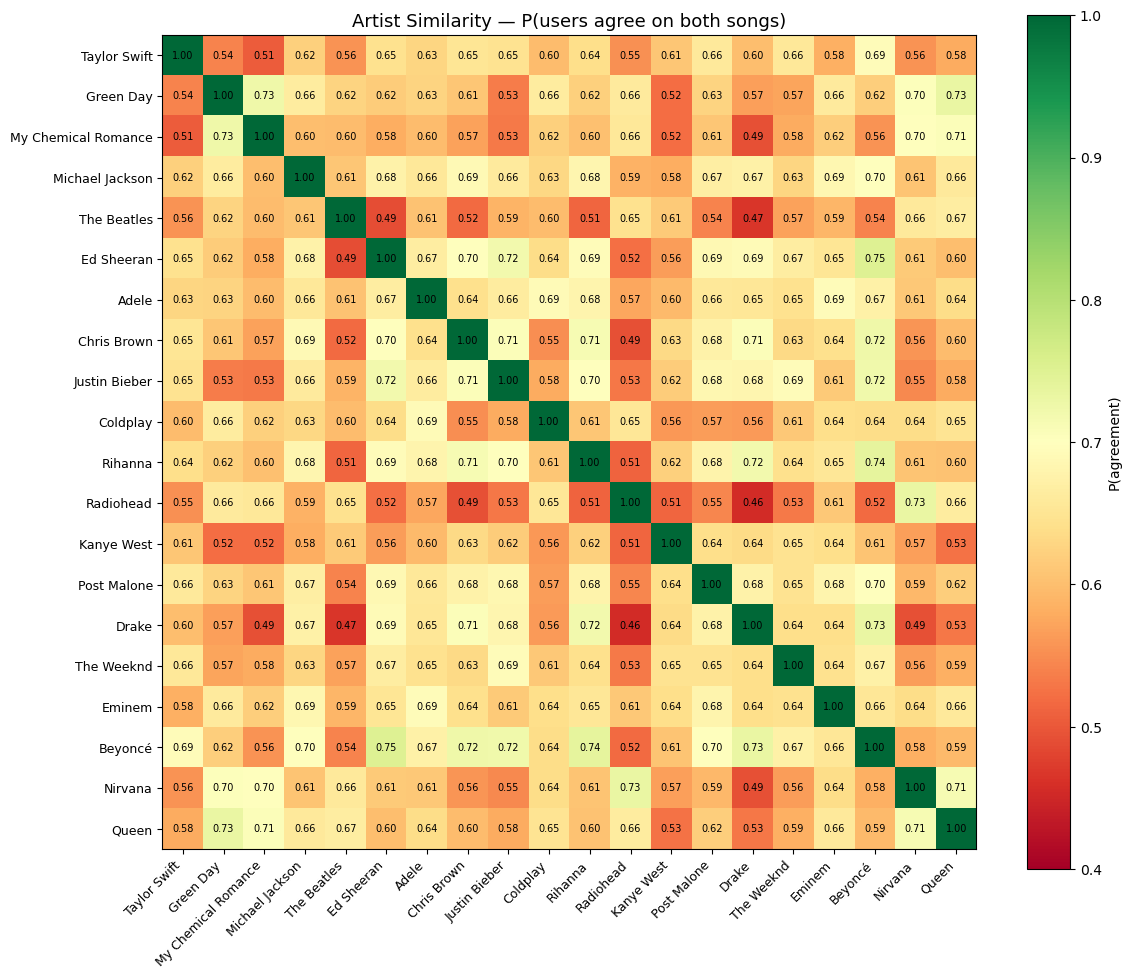

In [27]:
# Compute pairwise agreement matrix
sim = np.zeros((n, n))

for i in range(n):
    sim[i, i] = 1.0  # perfect agreement with itself
    for j in range(i + 1, n):
        result = get_song_agreement(top20_songs[i]['song_id'], top20_songs[j]['song_id'])
        p = float(result['p_agreement']) if result['shared_users'] else 0.5
        sim[i, j] = p
        sim[j, i] = p

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(sim, vmin=0.4, vmax=1.0, cmap='RdYlGn')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

# Annotate cells
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim[i, j]:.2f}', ha='center', va='center',
                fontsize=7, color='black')

plt.colorbar(im, ax=ax, label='P(agreement)')
ax.set_title('Artist Similarity — P(users agree on both songs)', fontsize=13)
plt.tight_layout()
plt.show()